### note
from v0 (deleted, incorrect hidden state encoding)<br/>
sine, dampling testing

In [1]:
# import libraries 
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

import numpy as np
import time
import copy

import pennylane as qml
import matplotlib.pyplot as plt

import pickle

In [2]:
class QGRUCirc:
    def __call__(self, inputs, weights):
        # inputs: includes type, inputs and hiddens
        
        # type: 0: without H ending; 1: with H ending
        H_ending = inputs[0] == 1
        # inputs
        qml.RX(inputs[1]*weights[0]+weights[1], wires=0)
        # initialize hidden state
        qml.RX(torch.arcsin(inputs[2])*weights[2]+weights[3], wires=1)
        qml.RX(torch.arcsin(inputs[3])*weights[4]+weights[5], wires=2)
        qml.RX(torch.arcsin(inputs[4])*weights[6]+weights[7], wires=3)
        qml.RX(torch.arcsin(inputs[5])*weights[8]+weights[9], wires=4)
        qml.RY(torch.arcsin(inputs[6])*weights[10]+weights[11], wires=1)
        qml.RY(torch.arcsin(inputs[7])*weights[12]+weights[13], wires=2)
        qml.RY(torch.arcsin(inputs[8])*weights[14]+weights[15], wires=3)
        qml.RY(torch.arcsin(inputs[9])*weights[16]+weights[17], wires=4)
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 4])
        qml.Barrier(wires=range(5))
        # gates
        qml.CNOT(wires=[0, 1])
#         qml.CSWAP(wires=[1, 2, 5])
        qml.RX(weights[18], wires=1)
#         qml.CSWAP(wires=[1, 4, 6])
        qml.Barrier(wires=range(5))
        # layer 1
        qml.RX(weights[19], wires=0)
        qml.RX(weights[20], wires=1)
        qml.RX(weights[21], wires=2)
        qml.RX(weights[22], wires=3)
        qml.RX(weights[23], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        qml.Barrier(wires=range(5))
        # layer 2
        qml.RY(weights[24], wires=0)
        qml.RY(weights[25], wires=1)
        qml.RY(weights[26], wires=2)
        qml.RY(weights[27], wires=3)
        qml.RY(weights[28], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        
        # ending
        if H_ending:
            qml.Hadamard(wires=[1])
            qml.Hadamard(wires=[2])
            qml.Hadamard(wires=[3])
            qml.Hadamard(wires=[4])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(5)]
        

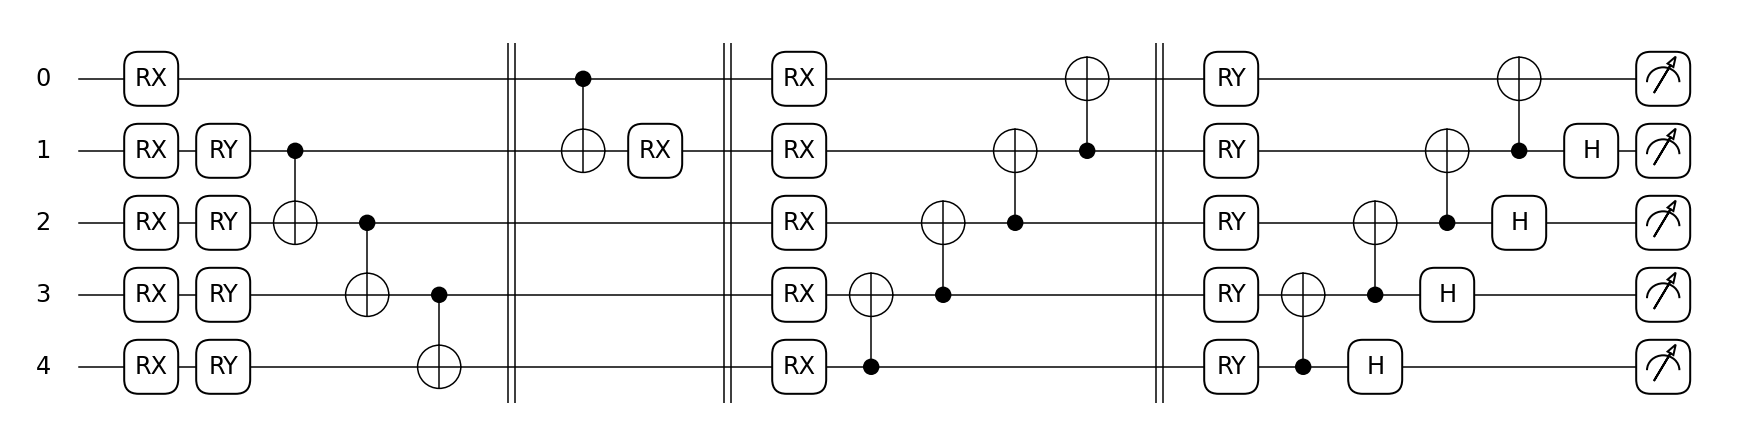

In [3]:
# https://pennylane.readthedocs.io/en/stable/code/api/pennylane.draw_mpl.html

qml.drawer.use_style('black_white')
dev = qml.device("default.qubit", wires=8)
qcirc = QGRUCirc()
qnode = qml.QNode(qcirc, dev)

fig, _ = qml.draw_mpl(qnode, fontsize=24)(torch.cat((torch.tensor([1]),torch.rand(10)),0),range(29))

In [4]:
#class QNode(func, device, interface='autograd', diff_method='best', mutable=True,
#max_expansion=10, h=1e-07, order=1, shift=1.5707963267948966, adjoint_cache=True, argnum=None, **kwargs)

class QGRU(nn.Module):
    def __init__(self):
        super(QGRU, self).__init__()
        
        dev = qml.device("default.qubit", wires=7)
        circuit = QGRUCirc()
        qnode = qml.QNode(circuit, dev)
        
        self.weight_shapes = {"weights": 29}
        self.qgru = qml.qnn.TorchLayer(qnode, self.weight_shapes)
        self.hidden_size = 4*2
                
    def forward(self, inputs, hiddens=None):
        # Currently, input dim=1, hidden dim=4x2
        in_dim = 1
        
        single = len(inputs.size()) == 1
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
#         if len(inputs.size()) == 1:
#             if hiddens == None:
#                 hiddens = torch.zeros(self.hidden_size)
#             Xs1 = torch.cat((torch.zeros(1), inputs, hiddens))
#             Xs2 = torch.cat((torch.ones(1), inputs, hiddens))
#         else:
            
            
        if hiddens == None:
            hiddens = torch.zeros([inputs.size(0), self.hidden_size])
        Xs1 = torch.cat((torch.zeros([inputs.size(0), 1]), inputs, hiddens), 1)
        Xs2 = torch.cat((torch.ones([inputs.size(0), 1]), inputs, hiddens), 1)
            
        Ys1 = self.qgru(Xs1)
        Ys2 = self.qgru(Xs2)
        
        outputs = (Ys1[:,0:in_dim] + Ys2[:,0:in_dim]) / 2
        Hs1 = Ys1[:, in_dim:]
        Hs2 = Ys2[:, in_dim:]
        
        Ys = torch.cat((outputs, Hs1, Hs2), 1)
        
        if single:
            Ys = Ys[0]
            
        return Ys # Currently, output dim=5
    

## Sequence (to make a RNN)

In [5]:
class Sequence(nn.Module):
    def __init__(self, initial_weight=None):
        super(Sequence, self).__init__()
        
        self.qgru = QGRU()
        self.out_size = 1
#         self.h_0 = torch.zeros(self.qgru.num_of_hidden)

    def forward(self, inputs, future = 0):
        # inputs: tensor
        # [[a1, a2, a3, ...]...] or [[[a1, a2, a3, ...]...]...]
        
        single = len(inputs.size()) == 2
        
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
        ht = None
        outSeq = torch.tensor([])
        
        for Xs in torch.transpose(inputs, 0, 1):
            Ys = self.qgru(Xs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        # future: only for the same types of input and output
        # the last outputs are used fot next inputs
        for _ in range(future):
            Ys = self.qgru(outs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        if single:
            outSeq = outSeq[0]
            
        return outSeq
   

## Sine

In [ ]:
sine = ((torch.tensor([np.sin(_*0.4) for _ in range(151)])*0.5)).float()
sineInput = sine[:-51]
sineTarget = sine[1:len(sineInput)+1]

sineInput = sineInput.reshape([len(sineInput),1])
sineTarget = sineTarget.reshape([len(sineTarget),1])

sineInput_a = sine[:-1]
sineInput_a = sineInput_a.reshape([len(sineInput_a),1])

plt.scatter(range(len(sine)), sine, s=3)
plt.ylim(-1,1)
plt.show()

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(sineInput)
    
    # Compute and print loss
    loss = criterion(prediction, sineTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

## Damping

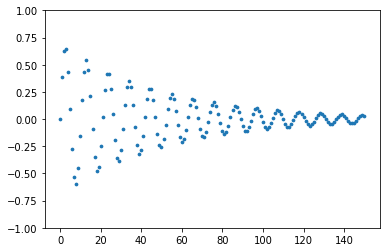

In [6]:
damp = ((torch.tensor([np.sin(_*0.6)*np.exp(_*-0.02) for _ in range(151)])*0.7)).float()
dampInput = damp[:-51]
dampTarget = damp[1:len(dampInput)+1]

dampInput = dampInput.reshape([len(dampInput),1])
dampTarget = dampTarget.reshape([len(dampTarget),1])

dampInput_a = damp[:-1]
dampInput_a = dampInput_a.reshape([len(dampInput_a),1])

plt.scatter(range(len(damp)), damp, s=3)
plt.ylim(-1,1)
plt.show()

In [18]:
np.random.seed(3)
torch.manual_seed(3)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for t in range(1000):
    prediction = model.forward(dampInput)
    
    # Compute and print loss
    loss = criterion(prediction, dampTarget)
    if loss.item() <= minLoss:
        minLoss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    curtime = time.time()
    print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
    if t % 10 == 9:
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
        lossList.append(loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

9: 0.07185196131467819  52.23631453514099        
19: 0.09673942625522614  107.14472079277039       
29: 0.08140601217746735  158.33111119270325       
39: 0.07198653370141983  209.53730964660645       
49: 0.06679593771696091  263.8483865261078        
59: 0.06517673283815384  317.90743589401245       
69: 0.0646185576915741  370.80108189582825        
79: 0.06441673636436462  422.76360630989075       
89: 0.06434259563684464  476.0009751319885        
99: 0.06431525200605392  533.4598636627197        
109: 0.0643051341176033  625.3930640220642        
119: 0.06430134177207947  682.3031523227692       
129: 0.06429984420537949  736.086065530777        
139: 0.06429923325777054  791.7802402973175       
149: 0.06429890543222427  856.3202474117279       
159: 0.06429871916770935  910.098230600357        
169: 0.06429854780435562  966.2505912780762       
179: 0.06429838389158249  1023.3513288497925       
189: 0.06429822742938995  1549.0878579616547       
199: 0.06429806351661682  1609

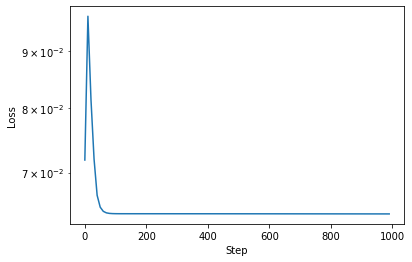

In [19]:
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [20]:
best_model = Sequence()
best_model.load_state_dict(best_state)
bestPredict = best_model(dampInput, 50).detach()

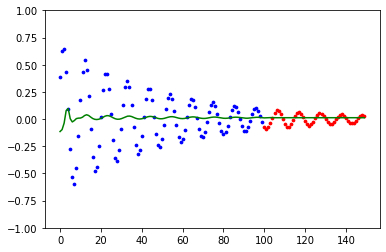

In [21]:
bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

### all data

In [ ]:
allInput = torch.cat((torch.unsqueeze(sineInput, 0), torch.unsqueeze(sineInput, 0)))
allTarget = torch.cat((torch.unsqueeze(dampTarget, 0), torch.unsqueeze(dampTarget, 0)))

## Batch loader

In [ ]:
class MyDataset(Dataset):

    # data loading
    def __init__(self, xs, ys):
        self.x = xs
        self.y = ys
        self.n_samples = len(xs)

    # working for indexing
    def __getitem__(self, index):
        
        return self.x[index], self.y[index]

    # return the length of our dataset
    def __len__(self):
        
        return self.n_samples

In [ ]:
dataset = MyDataset(allInput, allTarget)
dataloader = DataLoader(dataset=dataset, batch_size=2, shuffle=True)

In [ ]:
seed = np.random.randint(1000)
seed

In [ ]:
np.random.seed(0)
torch.manual_seed(0)
model = Sequence()

start_time = time.time()
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
minLoss = 100000
lossList = []

for epoch in range(500):
    loss_total = 0.0
    n = 0
    for inpSeqC, testTargetC in dataloader:
        n += 1
        
        prediction = model.forward(inpSeqC)

        # Compute and print loss
        loss = criterion(prediction, testTargetC)
        loss_total += loss.item()

        curtime = time.time()
        print('{}, {}: {}  {}       '.format(epoch, n, loss.item(), curtime-start_time), end='\r')

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    loss_avg = loss_total / n # loss per batch
    if epoch % 10 == 9:
        print('{}, avg.: {}  {}       '.format(epoch, loss_avg, curtime-start_time))
        lossList.append(loss_avg)
        
    if loss_avg <= minLoss:
        minLoss = loss_avg
        best_state = copy.deepcopy(model.state_dict())

In [ ]:
plt.clf()
plt.plot([x*10 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

In [ ]:
best_model = Sequence()
best_model.load_state_dict(best_state)

In [ ]:
bestPredict = best_model(sineInput, 50).detach()

In [ ]:
bp = bestPredict.tolist()
ta = sineTarget.tolist()
tb = sine[len(sineInput)+1:].tolist()
plt.clf()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [7]:
seeds = [np.random.randint(0, 1000) for _ in range(10)]
seeds = [847, 288, 794, 108, 945, 471, 300, 813, 359, 445]
seeds

[847, 288, 794, 108, 945, 471, 300, 813, 359, 445]

In [8]:
def damping_test(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = Sequence()

    start_time = time.time()
    criterion = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    minLoss = 100000
    lossList = []

    for t in range(1000):
        prediction = model.forward(dampInput)

        # Compute and print loss
        loss = criterion(prediction, dampTarget)
        if loss.item() <= minLoss:
            minLoss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        curtime = time.time()
        print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time), end='\r')
        if t % 10 == 9:
            print('{}: {}  {}       '.format(t, loss.item(), curtime-start_time))
            lossList.append(loss.item())

        # Zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return lossList, best_state

In [9]:
def plotPNG(seed, loss, bState):
    plt.clf()
    plt.plot([x*10 for x in range(len(loss))], loss)
    plt.ylabel('Loss')
    plt.xlabel('Step')
    plt.yscale("log")
    plt.savefig('loss_' + str(seed) + '.png')
    
    best_model = Sequence()
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    
    bp = bestPredict.tolist()
    ta = dampTarget.tolist()
    tb = damp[len(dampInput)+1:].tolist()
    plt.clf()
    plt.scatter(range(len(ta)), ta, c='b', s=3)
    plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
    plt.plot(bp, c='g')
    plt.ylim(-1,1)
    plt.savefig('result_' + str(seed) + '.png')
    

seed: 847
9: 0.04967021942138672  46.0998420715332         
19: 0.02055651694536209  93.99375057220459        
29: 0.020527875050902367  142.46297788619995       
39: 0.018803982064127922  190.88730359077454       
49: 0.01824650540947914  239.0936906337738         
59: 0.01777312345802784  286.90115904808044        
69: 0.017507236450910568  335.7117941379547        
79: 0.017239071428775787  383.616418838501         
89: 0.016928348690271378  431.40628933906555       
99: 0.01647132821381092  479.2144730091095         
109: 0.015524499118328094  526.7035961151123        
119: 0.013717154040932655  575.7802720069885       
129: 0.010374868288636208  623.8628356456757       
139: 0.009363170713186264  672.5475015640259       
149: 0.010093528777360916  720.6577272415161       
159: 0.007517293095588684  768.449937582016        
169: 0.010434768162667751  816.3580095767975       
179: 0.008702517487108707  864.2196419239044       
189: 0.007990495301783085  912.4677214622498       
199:

149: 0.07687258720397949  700.4586229324341       
159: 0.0768725723028183  747.1196684837341        
169: 0.0768725723028183  793.784738779068        
179: 0.0768725723028183  840.9561321735382       
189: 0.0768725723028183  887.5891587734222       
199: 0.0768725723028183  934.3905091285706       
209: 0.0768725723028183  981.3130834102631       
219: 0.0768725723028183  1028.16370511055         
229: 0.0768725723028183  1075.0192725658417       
239: 0.0768725723028183  1121.6890678405762       
249: 0.0768725723028183  1168.4443521499634       
259: 0.0768725723028183  1215.2658417224884       
269: 0.0768725723028183  1261.8950746059418       
279: 0.0768725723028183  1309.0139834880829       
289: 0.0768725723028183  1355.8430650234222       
299: 0.0768725723028183  1402.8549807071686       
309: 0.0768725723028183  1450.1458222866058       
319: 0.0768725723028183  1496.960282087326        
329: 0.0768725723028183  1543.6040725708008       
339: 0.0768725723028183  1590.442857

299: 0.06334317475557327  1404.1617181301117       
309: 0.0633431002497673  1450.9068930149078        
319: 0.06334291398525238  1497.637312412262        
329: 0.06334297358989716  1544.4685683250427       
339: 0.06334278732538223  1591.3060212135315       
349: 0.06334266066551208  1638.3773970603943       
359: 0.06334260106086731  1685.0797729492188       
369: 0.06334248930215836  1732.2079362869263       
379: 0.06334245949983597  1779.4541501998901       
389: 0.06334239989519119  1826.2590808868408       
399: 0.06334226578474045  1873.250170469284        
409: 0.0633421540260315  1920.2599539756775        
419: 0.0633421465754509  1967.243007659912         
429: 0.06334193795919418  2014.0486578941345       
439: 0.06334184855222702  2061.024126768112        
449: 0.06334179639816284  2107.851185321808        
459: 0.06334171444177628  2154.77077627182         
469: 0.0633416399359703  2201.7187039852142        
479: 0.06334157288074493  2248.7355484962463       
489: 0.06334

369: 0.08956405520439148  1744.0085048675537       
379: 0.08956405520439148  1790.7085061073303       
389: 0.08956405520439148  1837.9795987606049       
399: 0.08956405520439148  1885.0988380908966       
409: 0.08956405520439148  1932.379432439804        
419: 0.08956405520439148  1979.1802620887756       
429: 0.08956405520439148  2025.825192451477        
439: 0.08956405520439148  2073.2140231132507       
449: 0.08956405520439148  2120.047461748123        
459: 0.08956405520439148  2167.2193670272827       
469: 0.08956405520439148  2214.0651824474335       
479: 0.08956405520439148  2260.9613733291626       
489: 0.08956405520439148  2305.960670232773        
499: 0.08956405520439148  2352.6588430404663       
509: 0.08956405520439148  2399.657042503357        
519: 0.08956405520439148  2446.4172835350037       
529: 0.08956405520439148  2493.129065990448        
539: 0.08956405520439148  2540.227216243744        
549: 0.08956405520439148  2587.2361540794373       
559: 0.08956

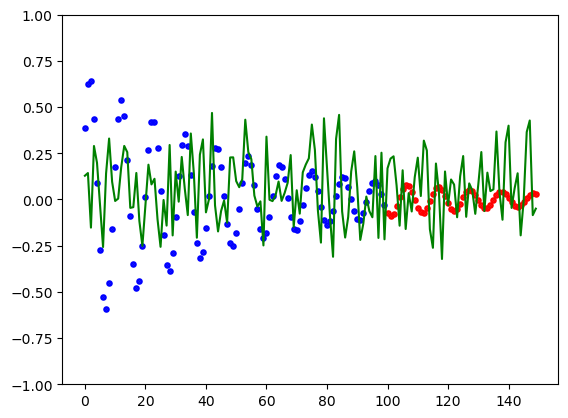

In [10]:
lossA = []
bStateA = []
for seed in seeds:
    print('seed:', seed)
    loss, bState = damping_test(seed)
    lossA.append(loss)
    bStateA.append(bState)
    
    # plot to file
    plotPNG(seed, loss, bState)

In [28]:
best_model = Sequence()
loss = 0
for bState in bStateA:
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    loss += criterion(bestPredict[101:], damp[101:]).item()
    
loss

C:\ProgramData\Anaconda3\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([50])) that is different to the input size (torch.Size([49, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0.19445968163199723

In [ ]:
seeds[6]

In [11]:
bState = bStateA[0]

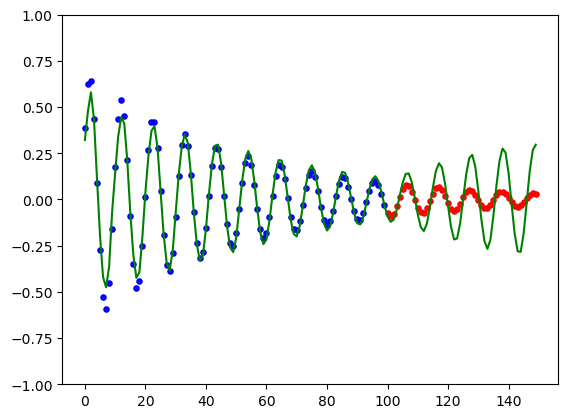

In [12]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(dampInput, 50).detach()

bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

In [ ]:
# ys2 = ((torch.tensor([np.sin(_*0.5) for _ in range(151)])*0.5)).float()
ys2 = ((torch.tensor([np.sin(_*0.55)*np.exp(_*0.01) for _ in range(151)])*0.2)).float()
testInput2 = ys2[:-51]
testTarget2 = ys2[1:len(testInput)+1]

testInput2 = testInput2.reshape([len(testInput2),1])
testTarget2 = testTarget2.reshape([len(testTarget2),1])

In [ ]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict2 = best_model(testInput2, 50).detach()

bp2 = bestPredict2.tolist()
ta2 = testTarget2.tolist()
tb2 = ys2[len(testInput2)+1:].tolist()
plt.plot(range(len(ta2)), ta2, c='c')
plt.plot(np.array(range(len(tb2)))+len(ta2), tb2, c='pink')
plt.plot(bp2, c='g')
plt.ylim(-1,1)
plt.show()

## Save / Load

In [11]:
with open('lossA.pickle', 'wb') as f:
    pickle.dump(lossA, f)
with open('bStateA.pickle', 'wb') as f:
    pickle.dump(bStateA, f)

In [ ]:
with open('bStateA.pickle', 'rb') as f:
    bStateA = pickle.load(f)